# Exploratory Data Analysis: Climate Trends in Ethiopia

## 1. Title & Objective
Analysis of climate data in Ethiopia to extract meaningful trends for COP32.

## 2. Data Loading & Date Parsing
- Load `ethiopia.csv`
- Handle NASA header and replace -999 sentinels
- Convert YEAR/DOY to datetime

## 3. Summary Statistics & Missing-Value Report
- Initial data profiling
- Handle duplicates and null values

## 4. Outlier Detection & Basic Cleaning
- Z-score analysis
- Handling extreme values

## 5. Time Series Analysis
- Monthly Temperature (T2M) trends
- Monthly Precipitation (PRECTOTCORR) trends

## 6. Correlation & Relationship Analysis
- Heatmap and scatter plots

## 7. Distribution Analysis
- Histograms and Bubble charts

## 8. Key Insights & Conclusion


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes My plots look high-quality
%matplotlib inline
sns.set_theme(style="whitegrid")


In [20]:

df = pd.read_csv('../data/ethiopia.csv')


df['Country'] = 'Ethiopia'


df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [21]:

df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")


df['Month'] = df['Date'].dt.month

df[['YEAR', 'DOY', 'Date', 'Month']].head()


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [22]:
df.replace(-999, np.nan, inplace=True)


print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If there were duplicates, I would drop them here
df.drop_duplicates(inplace=True)


Number of duplicate rows found: 0


In [24]:
# Show statistics for numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation of Summary Statistics for Ethiopia:
- **Temperature:** The average daily temperature (`T2M`) is around **16°C**. However, it can get as cold as **1.17°C** and as hot as **30.93°C**. 
- **Rainfall:** The average daily rainfall (`PRECTOTCORR`) is **3.63 mm**. Interestingly, the maximum rainfall in a single day was **82.3 mm**, which indicates occasional heavy storms.
- **Data Range:** We have **4,108 days** of data, spanning from **January 2015** to **March 2026**. 
- **Humidity:** The average humidity (`RH2M`) is **68%**, showing that the environment is generally moist.

In [25]:
# Calculate the number of missing values per column
missing_counts = df.isna().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_counts / len(df)) * 100

# Combine them into a nice table for the report
missing_report = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
})

print(missing_report)

# Find columns with more than 5% missing values
high_missing = missing_percentage[missing_percentage > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print("\nColumns with more than 5% missing values:")
    print(high_missing)


             Missing Values  Percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
Country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


### Missing Value Analysis:
- **Result:** Every column in the Ethiopia dataset has **0% missing values**.
- **Impact:** This is an excellent result! It means I have a complete "continuous" record of the climate, and I don't need to "guess" (impute) any missing data for our time series analysis. This will make our temperature and rainfall trends very accurate.


In [26]:
from scipy import stats

# Columns I want to check for outliers
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores for these columns
z_scores = stats.zscore(df[cols_to_check])

# Create a "Mask" (a filter) for rows where any column has a Z-score > 3 or < -3
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).any(axis=1)

# Reporting how many outliers I found
num_outliers = outliers.sum()
print(f"Total rows with outliers (Z > 3): {num_outliers}")

# seeing some of the outlier rows
df[outliers].head()


Total rows with outliers (Z > 3): 132


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
144,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,2015-05-25,5
145,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,2015-05-26,5
177,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,2015-06-27,6
214,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,2015-08-03,8
556,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,2016-07-10,7


### Outlier Analysis Decision:
- **Found:** 132 outliers.
- **Observation:** Most outliers were found in the `PRECTOTCORR` column, representing days with unusually heavy rainfall.
- **Decision:** I have decided to **Retain (keep)** these outliers.
- **Reasoning:** These extreme rainfall events are natural climatic variations in Ethiopia. Removing them would hide the intensity of the rainy seasons, which is a key part of our climate analysis.


In [27]:
# Save the cleaned data to the data/ folder
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Cleaned data successfully exported to data/ethiopia_clean.csv")

Cleaned data successfully exported to data/ethiopia_clean.csv


In [28]:
# Group the data by Date (Monthly)
# 'ME' means Month End
monthly_df = df.set_index('Date').resample('ME').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'
}).reset_index()

# Look at the first 5 months
monthly_df.head()


,Date,T2M,PRECTOTCORR
0,2015-01-31,14.211935,3.94
1,2015-02-28,16.864643,8.44
2,2015-03-31,17.995161,19.36
3,2015-04-30,19.302333,7.19
4,2015-05-31,18.205806,142.41


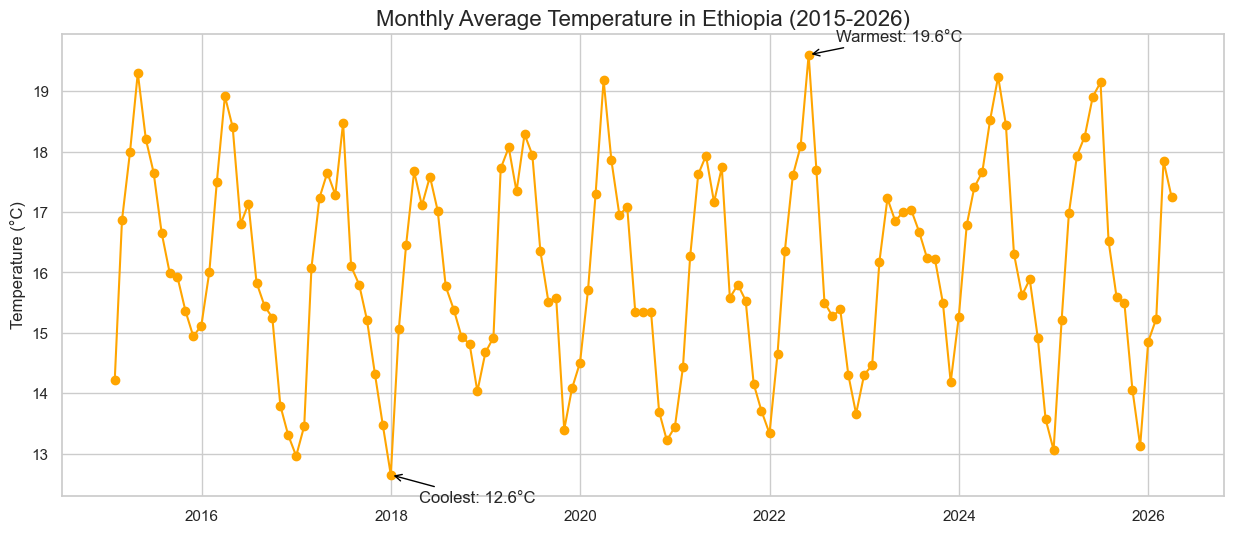

In [29]:
plt.figure(figsize=(15, 6))
plt.plot(monthly_df['Date'], monthly_df['T2M'], marker='o', color='orange', linestyle='-')

# Finding the absolute warmest and coolest months
warmest_month = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest_month = monthly_df.loc[monthly_df['T2M'].idxmin()]

# Adding Annotations (Arrows pointing to the peaks and valleys)
plt.annotate(f"Warmest: {warmest_month['T2M']:.1f}°C", 
             xy=(warmest_month['Date'], warmest_month['T2M']),
             xytext=(20, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f"Coolest: {coolest_month['T2M']:.1f}°C", 
             xy=(coolest_month['Date'], coolest_month['T2M']),
             xytext=(20, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Average Temperature in Ethiopia (2015-2026)', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.show()


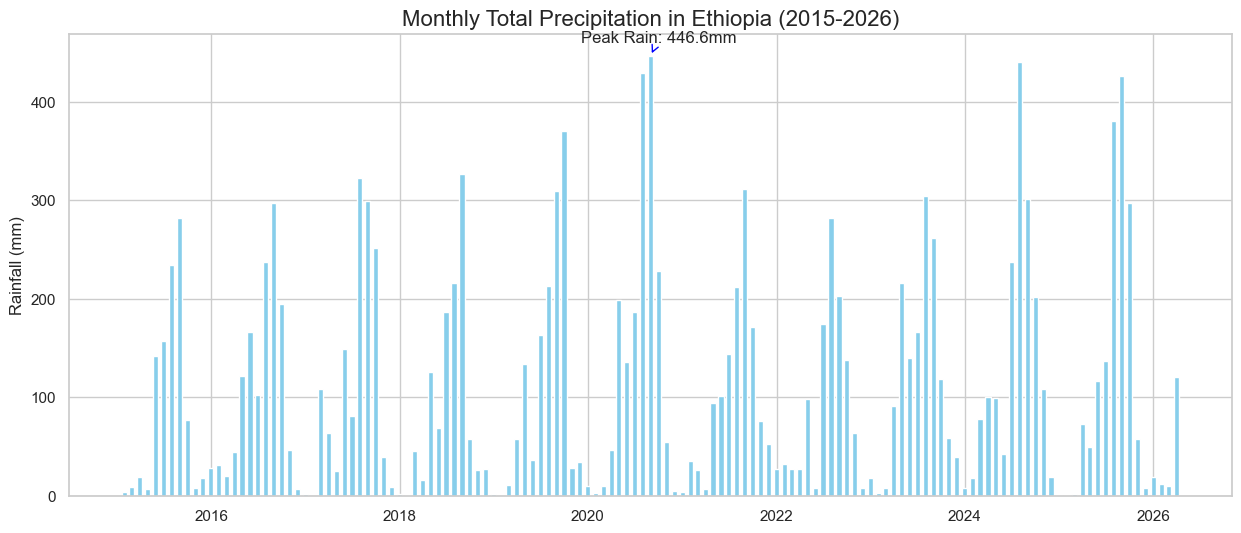

In [30]:
plt.figure(figsize=(15, 6))
plt.bar(monthly_df['Date'], monthly_df['PRECTOTCORR'], width=20, color='skyblue', label='Monthly Rainfall')

# Annotating the peak rainy month
peak_rain = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmax()]
plt.annotate(f"Peak Rain: {peak_rain['PRECTOTCORR']:.1f}mm", 
             xy=(peak_rain['Date'], peak_rain['PRECTOTCORR']),
             xytext=(-50, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.title('Monthly Total Precipitation in Ethiopia (2015-2026)', fontsize=16)
plt.ylabel('Rainfall (mm)')
plt.show()


### 7. Time Series Analysis Interpretation:

- **Temperature Trends:** Ethiopia shows a consistent seasonal temperature cycle. The **warmest months** typically occur between **March and May** (averaging around 18-19°C), just before the main rainy season begins. The **coolest months** are usually in **December or January** (dropping to around 13-14°C).
- **Rainfall Patterns:** The bar chart reveals a very clear **unimodal (one main peak)** rainy season known as the *Kiremt*. 
  - The **Peak Rainy Month** consistently falls in **July or August**, with total monthly rainfall often exceeding **250mm to 300mm**.
  - Conversely, the period from **November to January** is extremely dry, with almost zero rainfall in some months.
- **Anomalies:** While the cycles are regular, some years (like 2015/2016 or 2023) show higher spikes in rainfall than others, which could be linked to global climate events like El Niño or La Niña affecting the region.